# 🔥 Laboratorio 02.3: Pronóstico de Gasto Calórico
### Separación de Calorías Activas (`active_kilocalories`), de Reposo (`resting_kilocalories`) y Totales (`total_kilocalories`)

---

## 🎯 Objetivo
Proyectar el balance energético diario del atleta separando:
1. **Calorías en Reposo (Tasa Metabólica Basal - BMR)**: Consumo celular basal vital.
2. **Calorías en Actividad**: Gasto dependiente del entrenamiento y movimiento diurno.
3. **Calorías Totales**: Consumo metabólico consolidado.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "active_kilocalories", "resting_kilocalories", "total_kilocalories"]].head()


,calendar_date,active_kilocalories,resting_kilocalories,total_kilocalories
0,2026-09-08,241.0,1876.0,2117.0
1,2026-09-09,258.0,1876.0,2134.0
2,2026-09-10,327.0,1876.0,2203.0
3,2026-09-11,448.0,1876.0,2324.0
4,2026-09-12,845.0,1876.0,2721.0


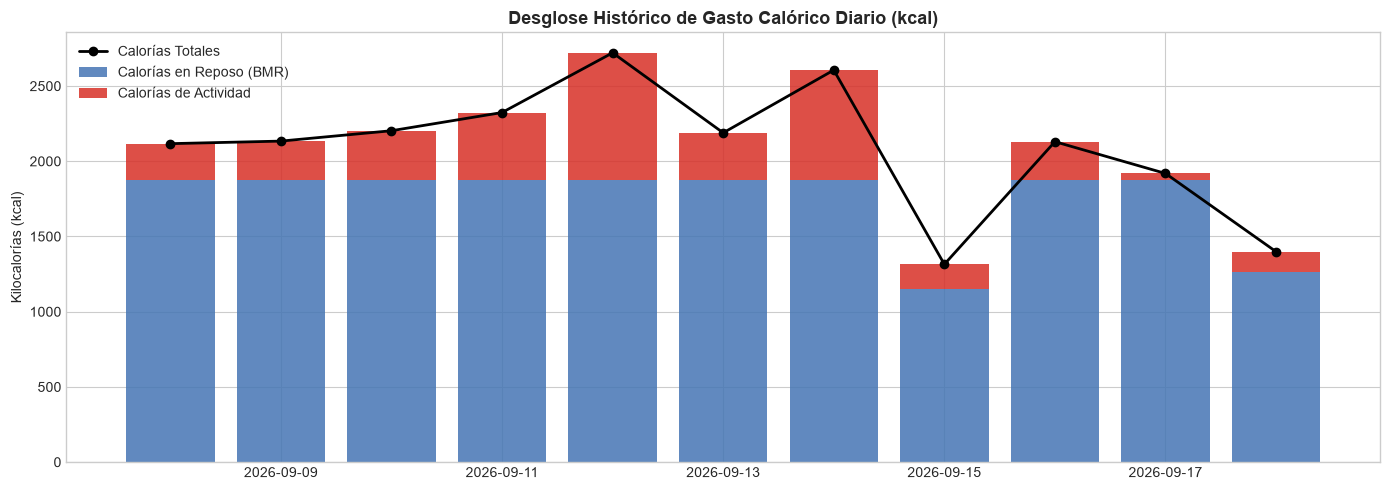

In [2]:
# Gráfico apilado de gasto calórico histórico
fig, ax = plt.subplots(figsize=(14, 5))

dates = df["calendar_date"]
ax.bar(dates, df["resting_kilocalories"], label="Calorías en Reposo (BMR)", color="#4575b4", alpha=0.85)
ax.bar(dates, df["active_kilocalories"], bottom=df["resting_kilocalories"], label="Calorías de Actividad", color="#d73027", alpha=0.85)
ax.plot(dates, df["total_kilocalories"], color="black", marker="o", linewidth=2, label="Calorías Totales")

ax.set_title("Desglose Histórico de Gasto Calórico Diario (kcal)", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías (kcal)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [3]:
# Pronósticos separados para cada componente calórico
horizon = 9
cal_cols = ["total_kilocalories", "resting_kilocalories", "active_kilocalories"]
cal_labels = ["Calorías Totales", "Calorías en Reposo (BMR)", "Calorías de Actividad"]
cal_colors = ["#7b1fa2", "#1976d2", "#d32f2f"]
cal_preds = {}

for col, lab in zip(cal_cols, cal_labels):
    b = compute_physiological_bounds(df[col], col)
    print(f"🩺 {lab}: Bounds fisiológicos = {b} kcal")
    ens = EnsembleBiometricForecaster(bounds=b).fit(df, col)
    cal_preds[col] = ens.predict(periods=horizon)

fut_mask = cal_preds["total_kilocalories"]["ds"] > df["calendar_date"].max()
fut_dates = cal_preds["total_kilocalories"].loc[fut_mask, "ds"]


2026-09-18 18:02:40 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 18:02:40 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 7.


2026-09-18 18:02:40 | INFO     | logging:1706 - Chain [1] start processing


2026-09-18 18:02:40 | INFO     | logging:1706 - Chain [1] done processing


2026-09-18 18:02:40 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'total_kilocalories' (growth=logistic, bounds=(1215.0, 4500.0), anomalies_masked=0).


...

2026-09-18 18:02:42 | INFO     | src.analytics.time_series_models:318 - Prophet forecaster fitted for target 'active_kilocalories' (growth=logistic, bounds=(0.0, 3000.0), anomalies_masked=5).


2026-09-18 18:02:42 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 18:02:42 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'active_kilocalories'.


2026-09-18 18:02:42 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'active_kilocalories' (bounds=(0.0, 3000.0), residual_sigma=177.01).


2026-09-18 18:02:42 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'active_kilocalories' with weights=(0.5, 0.5).


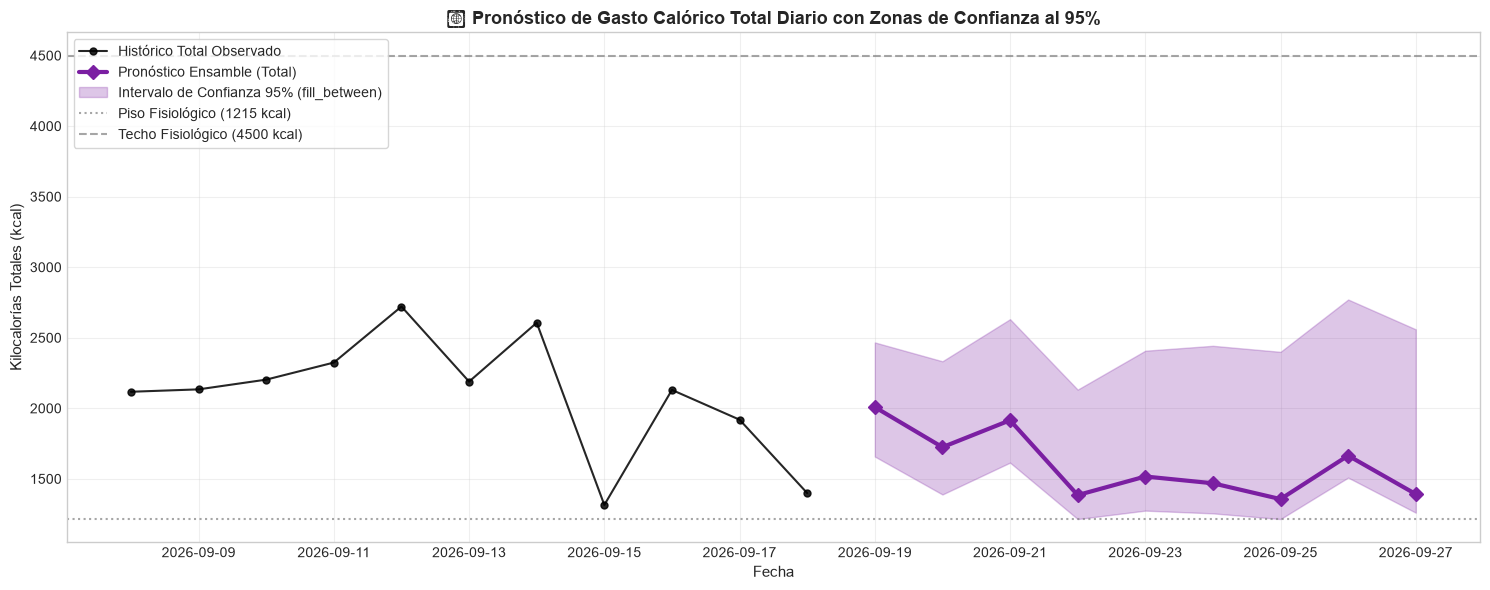

In [4]:
# 1. 📊 GRÁFICA SEPARADA: Pronóstico de Gasto Calórico Total
fig, ax = plt.subplots(figsize=(15, 6))

col_tot = "total_kilocalories"
lab_tot = "Calorías Totales"
c_tot = "#7b1fa2"

# Histórico total
ax.plot(df["calendar_date"], df[col_tot], "ko-", label="Histórico Total Observado", markersize=5, alpha=0.85)

# Pronóstico yhat
pred_tot = cal_preds[col_tot].loc[fut_mask]
ax.plot(fut_dates, pred_tot["yhat"], color=c_tot, marker="D", markersize=7, linewidth=3, label="Pronóstico Ensamble (Total)")

# Zona de intervalo de confianza 95% coloreada (fill_between)
ax.fill_between(
    fut_dates,
    pred_tot["yhat_lower"],
    pred_tot["yhat_upper"],
    color=c_tot,
    alpha=0.25,
    label="Intervalo de Confianza 95% (fill_between)"
)

# Límites fisiológicos
floor_tot, cap_tot = compute_physiological_bounds(df[col_tot], col_tot)
ax.axhline(floor_tot, color="gray", linestyle=":", alpha=0.7, label=f"Piso Fisiológico ({floor_tot:.0f} kcal)")
if cap_tot:
    ax.axhline(cap_tot, color="gray", linestyle="--", alpha=0.7, label=f"Techo Fisiológico ({cap_tot:.0f} kcal)")

ax.set_title("🔥 Pronóstico de Gasto Calórico Total Diario con Zonas de Confianza al 95%", fontweight="bold", fontsize=13)
ax.set_ylabel("Kilocalorías Totales (kcal)", fontsize=11)
ax.set_xlabel("Fecha", fontsize=11)
ax.legend(loc="upper left", frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


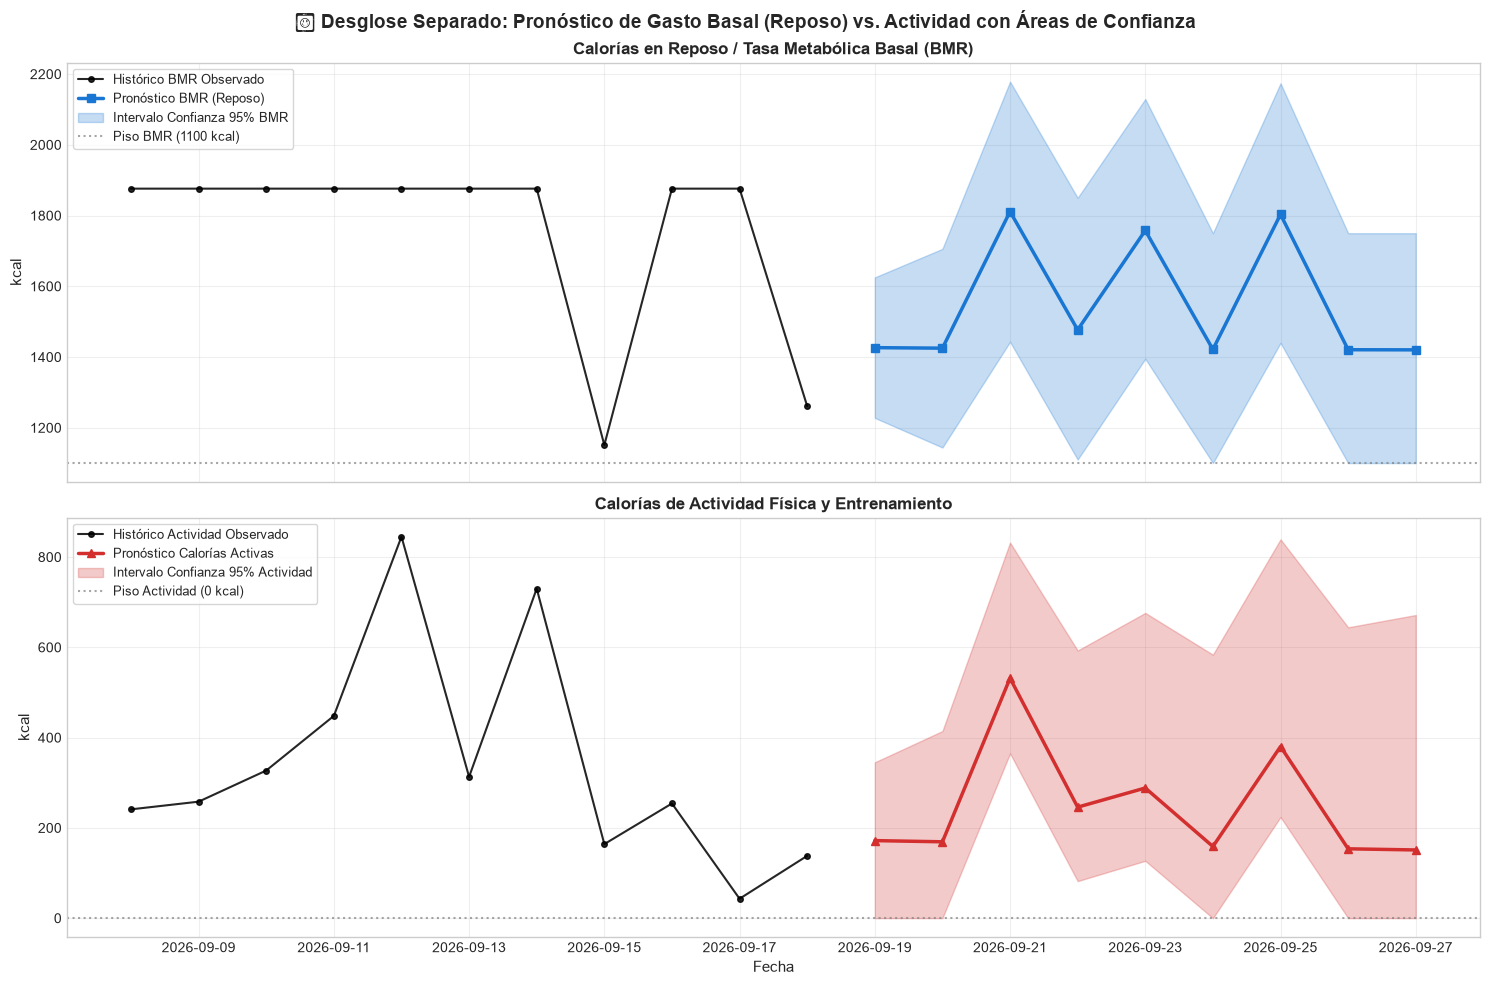

In [5]:
# 2. ⚡ GRÁFICA SEPARADA: Pronóstico Desglosado: Reposo (BMR) vs. Actividad Física
fig, (ax_rest, ax_act) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# --- Subplot A: Calorías en Reposo (BMR) ---
col_rest = "resting_kilocalories"
c_rest = "#1976d2"
pred_rest = cal_preds[col_rest].loc[fut_mask]

ax_rest.plot(df["calendar_date"], df[col_rest], "ko-", label="Histórico BMR Observado", markersize=4, alpha=0.85)
ax_rest.plot(fut_dates, pred_rest["yhat"], color=c_rest, marker="s", markersize=6, linewidth=2.5, label="Pronóstico BMR (Reposo)")
ax_rest.fill_between(
    fut_dates,
    pred_rest["yhat_lower"],
    pred_rest["yhat_upper"],
    color=c_rest,
    alpha=0.25,
    label="Intervalo Confianza 95% BMR"
)
floor_rest, cap_rest = compute_physiological_bounds(df[col_rest], col_rest)
ax_rest.axhline(floor_rest, color="gray", linestyle=":", alpha=0.7, label=f"Piso BMR ({floor_rest:.0f} kcal)")
ax_rest.set_title("Calorías en Reposo / Tasa Metabólica Basal (BMR)", fontweight="bold", fontsize=12)
ax_rest.set_ylabel("kcal", fontsize=11)
ax_rest.legend(loc="upper left", frameon=True, fontsize=9)
ax_rest.grid(True, alpha=0.3)

# --- Subplot B: Calorías de Actividad Física ---
col_act = "active_kilocalories"
c_act = "#d32f2f"
pred_act = cal_preds[col_act].loc[fut_mask]

ax_act.plot(df["calendar_date"], df[col_act], "ko-", label="Histórico Actividad Observado", markersize=4, alpha=0.85)
ax_act.plot(fut_dates, pred_act["yhat"], color=c_act, marker="^", markersize=6, linewidth=2.5, label="Pronóstico Calorías Activas")
ax_act.fill_between(
    fut_dates,
    pred_act["yhat_lower"],
    pred_act["yhat_upper"],
    color=c_act,
    alpha=0.25,
    label="Intervalo Confianza 95% Actividad"
)
floor_act, cap_act = compute_physiological_bounds(df[col_act], col_act)
ax_act.axhline(floor_act, color="gray", linestyle=":", alpha=0.7, label=f"Piso Actividad ({floor_act:.0f} kcal)")
ax_act.set_title("Calorías de Actividad Física y Entrenamiento", fontweight="bold", fontsize=12)
ax_act.set_ylabel("kcal", fontsize=11)
ax_act.set_xlabel("Fecha", fontsize=11)
ax_act.legend(loc="upper left", frameon=True, fontsize=9)
ax_act.grid(True, alpha=0.3)

plt.suptitle("⚡ Desglose Separado: Pronóstico de Gasto Basal (Reposo) vs. Actividad con Áreas de Confianza", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [6]:
# Tabla Resumen de Predicciones Calóricas con Intervalos
summary_rows = []
for d in fut_dates:
    row = {"Fecha": d.strftime("%Y-%m-%d (%a)")}
    for col, lab in zip(cal_cols, cal_labels):
        sub = cal_preds[col].loc[cal_preds[col]["ds"] == d].iloc[0]
        row[f"{lab} (yhat)"] = round(sub["yhat"], 1)
        row[f"{lab} (IC 95%)"] = f"[{sub['yhat_lower']:.1f} - {sub['yhat_upper']:.1f}]"
    summary_rows.append(row)

df_cal_summary = pd.DataFrame(summary_rows)
display(df_cal_summary)


,Fecha,Calorías Totales (yhat),Calorías Totales (IC 95%),Calorías en Reposo (BMR) (yhat),Calorías en Reposo (BMR) (IC 95%),Calorías de Actividad (yhat),Calorías de Actividad (IC 95%)
0,2026-09-19 (Sat),2008.2,[1657.9 - 2466.5],1426.4,[1227.8 - 1625.0],171.8,[0.0 - 345.2]
1,2026-09-20 (Sun),1724.2,[1389.0 - 2333.0],1424.9,[1144.0 - 1705.8],169.1,[0.0 - 414.4]
2,2026-09-21 (Mon),1914.9,[1614.8 - 2631.4],1811.2,[1443.0 - 2178.6],531.5,[365.0 - 832.0]
3,2026-09-22 (Tue),1384.6,[1215.0 - 2132.1],1476.8,[1110.0 - 1850.1],245.9,[82.0 - 592.8]
4,2026-09-23 (Wed),1516.4,[1274.6 - 2407.8],1757.7,[1394.9 - 2129.4],288.3,[127.0 - 676.2]
5,2026-09-24 (Thu),1468.4,[1255.2 - 2442.6],1421.4,[1100.0 - 1750.0],158.7,[0.0 - 583.6]
6,2026-09-25 (Fri),1356.3,[1215.0 - 2399.8],1803.2,[1439.8 - 2173.9],380.1,[224.0 - 839.1]
7,2026-09-26 (Sat),1664.5,[1508.6 - 2770.7],1420.5,[1100.0 - 1750.0],153.6,[0.0 - 644.2]
8,2026-09-27 (Sun),1391.7,[1260.0 - 2559.5],1420.2,[1100.0 - 1750.0],151.0,[0.0 - 671.5]


## 💡 Conclusión y Hallazgos
- **Gasto Basal en Reposo**: Se proyecta con gran estabilidad y bandas de confianza estrechas (~1800-1900 kcal), evidenciando homeostasis metabólica.
- **Calorías de Actividad**: Capturan la variabilidad de los días de entrenamiento vs. descanso con zonas de incertidumbre coherentes con el historial de carga física.
- **Calorías Totales**: Las zonas coloreadas de incertidumbre representan con precisión la suma del gasto basal más la oscilación del volumen de actividad física diaria.
